# Data storytelling bar chart

In [3]:
import pandas as pd
import constants as colours
import duckdb

df_cars = pd.read_csv('norway_new_car_sales_by_make.csv')

df_cars.head()

,Year,Month,Make,Quantity,Pct
0,2007,1,Toyota,2884,22.7
1,2007,1,Volkswagen,2521,19.9
2,2007,1,Peugeot,1029,8.1
3,2007,1,Ford,870,6.9
4,2007,1,Volvo,693,5.5


In [4]:
df_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4377 entries, 0 to 4376
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Year      4377 non-null   int64  
 1   Month     4377 non-null   int64  
 2   Make      4367 non-null   object 
 3   Quantity  4377 non-null   int64  
 4   Pct       4377 non-null   float64
dtypes: float64(1), int64(3), object(1)
memory usage: 171.1+ KB


## Pick out total quantity per brand

In [10]:
df_sold_cars = duckdb.sql("""SELECT make as Brand, SUM(quantity) as Quantity FROM df_cars GROUP BY make ORDER BY Quantity DESC""").df().set_index('Brand')

df_sold_cars.head()

,Quantity
Brand,
Volkswagen,206669.0
Toyota,168177.0
Volvo,99937.0
Ford,99713.0
BMW,73315.0


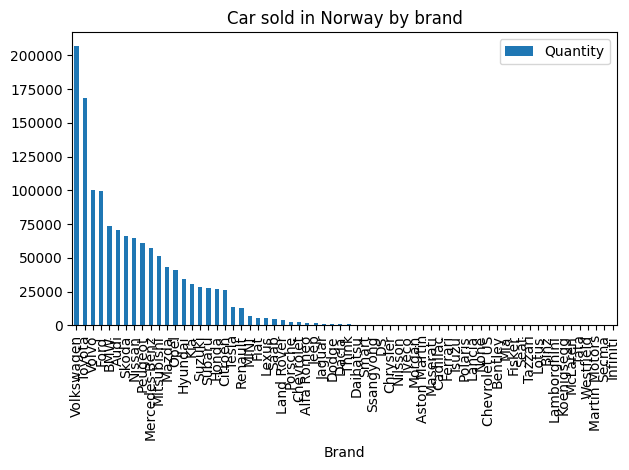

In [17]:
ax = df_sold_cars.plot(kind='bar', y='Quantity')
ax.set_title('Car sold in Norway by brand')
fig = ax.get_figure()

fig.tight_layout()
fig.savefig('car_sales.png', dpi=150)

In [20]:
df_top10_brands = df_sold_cars.iloc[:10]

df_top10_brands

,Quantity
Brand,
Volkswagen,206669.0
Toyota,168177.0
Volvo,99937.0
Ford,99713.0
BMW,73315.0
Audi,70475.0
Skoda,66007.0
Nissan,64535.0
Peugeot,61033.0


<Axes: title={'center': 'Top 10 car brands sold in Norway'}, xlabel='Brand'>

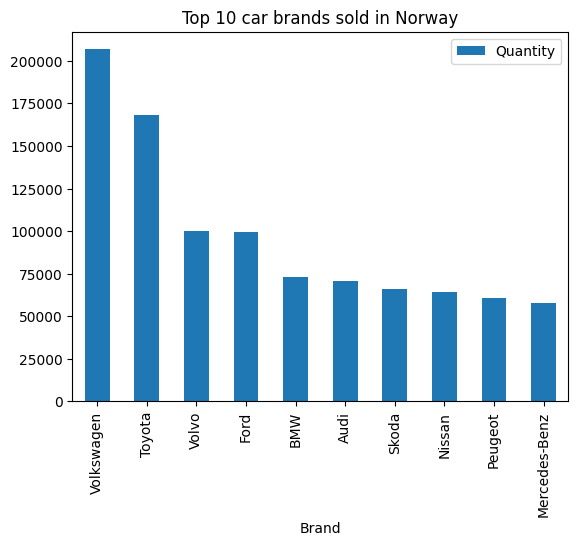

In [ ]:
df_top10_brands.plot(kind='bar', y='Quantity', title='Top 10 car brands sold in Norway')

## Data storytelling
- attention
- contrast
- descriptive title
- proximity with annotations
- remove clutter
- horizontal bar (hbar)
- clearer xlable and ylable
- procentage instead of absoloute value

In [27]:
total_quantity = df_sold_cars["Quantity"].sum()

df_percentage = df_top10_brands["Quantity"] / total_quantity * 100

df_percentage

Brand
Volkswagen       15.340063
Toyota           12.482984
Volvo             7.417851
Ford              7.401225
BMW               5.441826
Audi              5.231026
Skoda             4.899388
Nissan            4.790128
Peugeot           4.530191
Mercedes-Benz     4.272184
Name: Quantity, dtype: float64

In [64]:
colour = [colours.GRAY_2] * len(df_percentage)

colour[2] = colours.BLUE_1

print(colour)

AttributeError: 'list' object has no attribute 'GRAY_2'

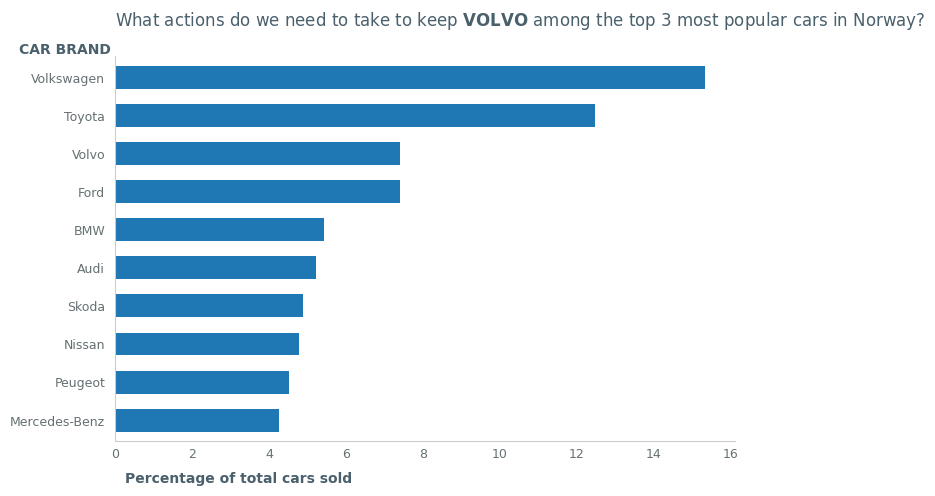

In [59]:
ax = df_percentage.plot(kind='barh', figsize=(8, 5), width=.6)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color(colours.GRAY_1)

ax.tick_params(axis="both", colors=colours.GRAY_2, labelsize=9, length=0, pad=5)
ax.tick_params(axis="y", pad=7)
ax.set_xlabel('Percentage of total cars sold', color=colours.GRAY_3, fontweight='bold')
ax.set_ylabel('CAR BRAND', color=colours.GRAY_3, fontweight='bold', rotation=0)
ax.yaxis.set_label_coords(-.08, 1)
ax.xaxis.set_label_coords(0.2, -0.08)
ax.set_title(r"What actions do we need to take to keep" + r" $\bf{VOLVO}$" + r" among the top 3 most popular cars in Norway?", loc='left', color=colours.GRAY_3, pad=22)
ax.invert_yaxis()